# 03, P-V cut examples

Per `plan.md` §11 step 3. Take 10 known B11 holes and 10 random
sightlines from the same galaxy and render their p-v cut windows.
Visual sanity: the catalogued holes should show the characteristic
ellipse / cavity signature; the random sightlines should not. If they
do, either the cube/catalog alignment from notebook 02 is off, or the
B11 catalog is mis-keyed.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from hishells.catalog import load_catalog
from hishells.cubes import load_cube, sigma_rms
from hishells.pvcut import extract_window_for_hole, window_extent_for_hole
from hishells.windows import NegSampleConfig, normalize_window, sample_negatives

In [2]:
REPO = Path('..').resolve()
DATA = REPO / 'Data' / 'THINGS'
GALAXY = 'NGC_2403'  # change me

cat = load_catalog(REPO / 'Data' / 'J_AJ_141_23')
cube = load_cube(DATA / f'{GALAXY}_NA_CUBE_THINGS.FITS')
sigma = sigma_rms(cube)
print(f'{GALAXY}: shape={cube.shape}, beam={cube.beam_bmaj_arcsec:.1f}", sigma_rms={sigma:.4g} Jy/beam')

NGC_2403: shape=(61, 2048, 2048), beam=8.8", sigma_rms=0.0003907 Jy/beam


In [3]:
# Pick 10 "textbook ellipse" holes: type-3 (two-sided expansion) so
# both walls of the p-v ellipse exist; axial_ratio ~ 1 so the
# projection is an actual ellipse and not a slit; Vexp > 5 km/s so
# the ellipse opens far enough to be visible across a few channels.
# This is the cleanest slice of B11 to eyeball pvcut.py against.
# Falls back to the prior "top by diameter" selector if too few rows
# pass, so the notebook still renders on galaxies with sparse type-3.
mask = (
    (cat.holes['galaxy_id'] == GALAXY)
    & (cat.holes['hole_type'] == 3)
    & (cat.holes['axial_ratio'].between(0.85, 1.0))
    & (cat.holes['vexp_kms'] > 5)
)
holes = (
    cat.holes[mask]
    .sort_values('diameter_pc', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
if len(holes) < 10:
    print(f'only {len(holes)} round type-3 holes in {GALAXY}; falling back to top type-{{2,3}} by diameter')
    holes = (
        cat.holes[(cat.holes['galaxy_id'] == GALAXY) & (cat.holes['hole_type'].isin([2, 3]))]
        .sort_values('diameter_pc', ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
else:
    print(f'showing {len(holes)} round type-3 holes in {GALAXY} (axial_ratio in [0.85, 1.0], Vexp > 5 km/s)')

showing 10 round type-3 holes in NGC_2403 (axial_ratio in [0.85, 1.0], Vexp > 5 km/s)


In [4]:
# Visualisation matches what the CNN sees at training time: each
# window is normalised by per-cube sigma_rms (same as
# `hishells.windows.normalize_window` in the dataset), then displayed
# on a *fixed* sigma-unit scale so cavities and walls look the same
# brightness across panels and across galaxies. The previous
# per-panel percentile stretch was rescaling each hole independently,
# which let bright outliers (p98 ~ 5--10 sigma) squeeze the cavity
# (~ -1.5 sigma) into a thin slice of dynamic range and visually
# erased the ellipse. -2..+5 sigma keeps the cavity in the dark third
# of magma and saturates the wall at the top.
VMIN_SIGMA, VMAX_SIGMA = -2.0, 5.0
WINDOW_PIX = 96
POS_FACTOR = 2.0  # window spans +/- POS_FACTOR * d_arcsec along position
VEL_FACTOR = 2.0  # window spans +/- max(VEL_FACTOR * Vexp, 20) km/s

def expected_ellipse_axes_pix(d_arcsec, vexp_kms,
                              window_pix=WINDOW_PIX,
                              pos_factor=POS_FACTOR,
                              vel_factor=VEL_FACTOR,
                              vel_floor_kms=20.0,
                              sigma_gas_kms=10.0):
    """Return (pos_semi, vel_semi) in window pixels for the (d, Vexp)
    ellipse the catalog says should sit in this window. Position
    semi-axis = d/2 maps to window_pix * (d/2) / (2 * pos_factor * d) =
    window_pix / (4*pos_factor). Velocity semi-axis = Vexp maps to
    window_pix * Vexp / (2 * vel_extent)."""
    ext = window_extent_for_hole(
        d_arcsec, vexp_kms, sigma_gas_kms=sigma_gas_kms,
        pos_factor=pos_factor, vel_factor=vel_factor,
        vel_floor_kms=vel_floor_kms,
    )
    pos_semi = (d_arcsec / 2.0) / (2.0 * ext.pos_extent_arcsec) * window_pix
    if vexp_kms is not None and np.isfinite(vexp_kms) and vexp_kms > 0:
        vel_semi = vexp_kms / (2.0 * ext.vel_extent_kms) * window_pix
    else:
        vel_semi = sigma_gas_kms / (2.0 * ext.vel_extent_kms) * window_pix
    return float(pos_semi), float(vel_semi)


def show_window(ax, win_raw, title, cube_sigma,
                hole=None, draw_ellipse=False,
                vmin=VMIN_SIGMA, vmax=VMAX_SIGMA):
    """Display one window in normalised sigma_rms units (model input).

    If ``draw_ellipse=True`` and ``hole`` carries (diameter_arcsec,
    vexp_kms), overlays the catalog's expected p-v ellipse so the eye
    can check whether the visible cavity/wall pattern lines up with
    what B11 reports. The window's position axis is vertical (axis 0)
    and velocity is horizontal (axis 1) under origin='lower'.
    """
    win = normalize_window(win_raw, cube_sigma)
    ax.imshow(win, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
    if draw_ellipse and hole is not None:
        d = float(hole.get('diameter_arcsec', np.nan))
        vexp = float(hole.get('vexp_kms', np.nan))
        sig_gas = float(hole.get('sigma_gas_kms', 10.0))
        if np.isfinite(d) and d > 0:
            pos_semi, vel_semi = expected_ellipse_axes_pix(
                d, vexp if np.isfinite(vexp) else 0.0,
                sigma_gas_kms=sig_gas,
            )
            cy = win.shape[0] / 2.0 - 0.5
            cx = win.shape[1] / 2.0 - 0.5
            # Ellipse(xy=(x, y), width=2*x_semi, height=2*y_semi);
            # x is velocity (axis 1), y is position (axis 0).
            ell = Ellipse((cx, cy), 2 * vel_semi, 2 * pos_semi,
                          fill=False, edgecolor='cyan', lw=1.0,
                          alpha=0.85)
            ax.add_patch(ell)
    ax.set_title(title, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

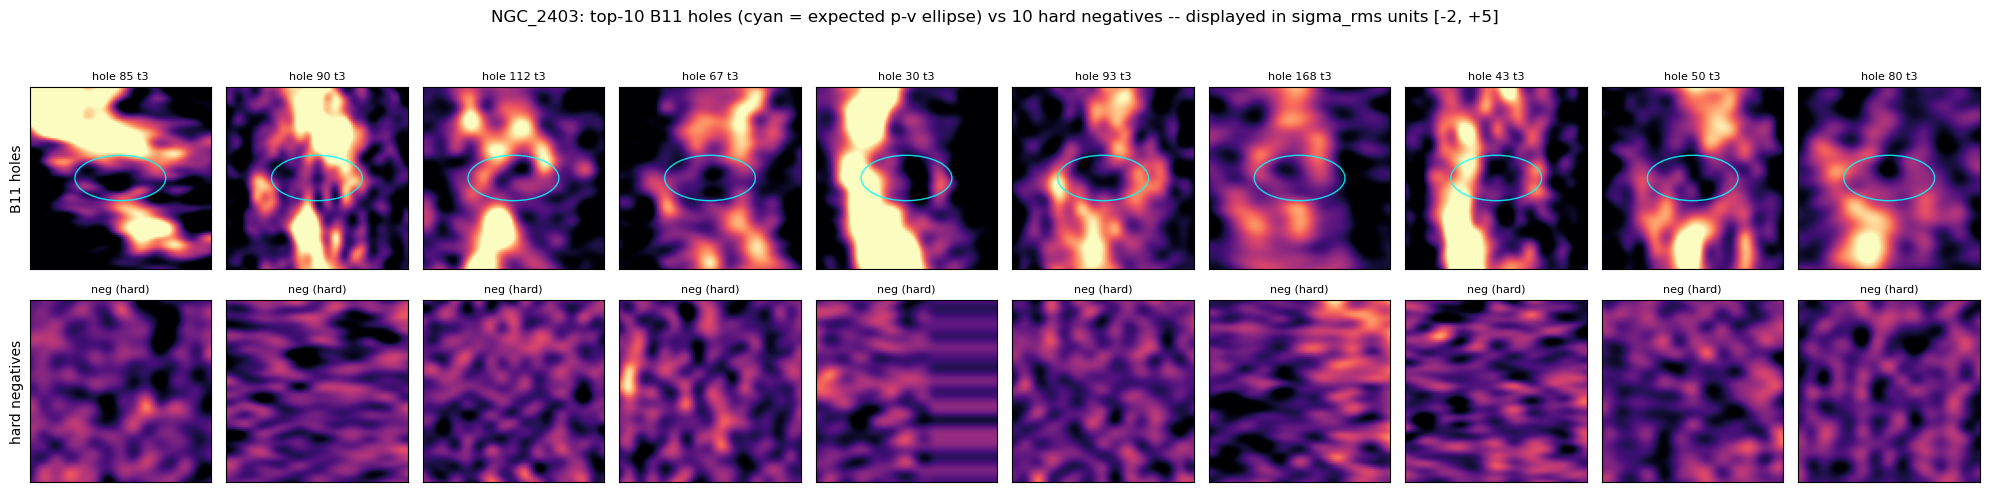

In [5]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for ax, (_, h) in zip(axes[0], holes.iterrows()):
    win = extract_window_for_hole(cube, h.to_dict(), window_pix=WINDOW_PIX)
    show_window(ax, win, f"hole {h.hole_idx} t{h.hole_type}",
                cube_sigma=sigma, hole=h.to_dict(), draw_ellipse=True)
axes[0, 0].set_ylabel('B11 holes', fontsize=10)

# Hard in-galaxy negatives -- the same sampler training uses, with
# hard_frac=1.0 so the bottom row is the hard discrimination case
# (matched window extents, offset by >= 2*diameter from any positive).
# Negatives keep the cyan ellipse off because there is no catalogued
# (d, Vexp) to draw -- the negative inherits these only to match
# window scale.
n_neg = 10
neg_cfg = NegSampleConfig(
    ratio=max(n_neg / max(len(holes), 1), 1.0),
    hard_frac=1.0,
    rng_seed=0,
)
negs = sample_negatives(cube, holes, neg_cfg).head(n_neg).reset_index(drop=True)
for ax, (_, n) in zip(axes[1], negs.iterrows()):
    win = extract_window_for_hole(cube, n.to_dict(), window_pix=WINDOW_PIX)
    show_window(ax, win, f"neg ({n.neg_kind})", cube_sigma=sigma)
axes[1, 0].set_ylabel('hard negatives', fontsize=10)
fig.suptitle(
    f'{GALAXY}: top-{len(holes)} B11 holes (cyan = expected p-v ellipse) '
    f'vs {len(negs)} hard negatives -- displayed in sigma_rms units '
    f'[{VMIN_SIGMA:+.0f}, {VMAX_SIGMA:+.0f}]',
    y=1.02,
)
plt.tight_layout()

## Pass criterion

Both rows now display the **exact tensor** the CNN sees at training
time (`normalize_window(window, sigma_rms)`), on a fixed
`[-2, +5] sigma_rms` colormap so panels are mutually comparable and
across-galaxy contrast is preserved. The previous per-panel percentile
stretch was independently rescaling each hole, which let bright
outliers (p98 ~ 5--10 sigma) compress the cavity (~ -1.5 sigma) into a
sliver of dynamic range and visually erased the ellipse even though
the slicer itself was correct.

* **Top row (B11 holes):** the cyan ellipse is the **catalog
  prediction** -- semi-axes `(d/2, Vexp)` mapped to window pixels (so
  the inner quarter in position and the half-width in velocity for
  default `pos_factor=vel_factor=2.0`). A textbook expanding shell
  shows the dark cavity *inside* the cyan curve and the bright wall
  *on* it. Mismatches between the cyan ellipse and the visible cavity
  point at catalog uncertainty (B11 `Vexp` is good to ~3--5 km/s and
  PA can be off on weakly-elongated holes), not at slicer bugs.
* **Bottom row (hard negatives):** in-galaxy patches drawn by
  `hishells.windows.sample_negatives` with `hard_frac=1.0`. Same
  display scale, no overlay because there is no catalogued ellipse.
  Expect emission with no consistent dark interior at the centre.
  This is the actual training-time discrimination task -- it should
  look visually harder than off-galaxy noise but qualitatively
  different from the positives.

If the positives still fail to show cavities inside the cyan ellipse
after this fix, suspect `pvcut.py` (PA rotation in `_sightline_pix`,
or the velocity-axis flip branch around lines 177--178) and run

```bash
pytest tests/test_pvcut.py -k pv_ellipse
```

to localise. That test asserts the synthetic-shell window has the
right velocity-axis cavity shape; if it passes, the issue is data, not
code, and the next step is `04_window_inspection.ipynb`'s diagnostics.